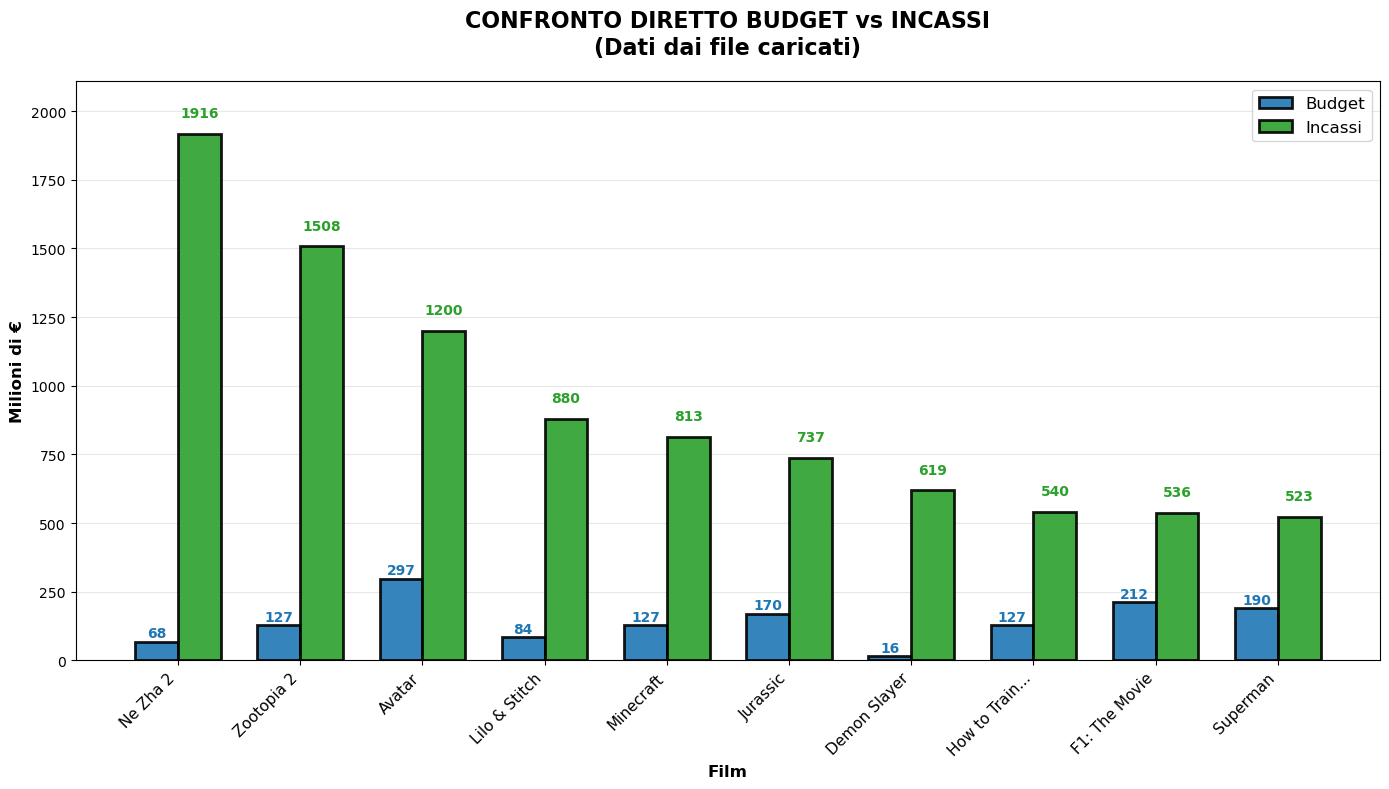

DATI EFFETTIVI USATI NEL GRAFICO:
Film                      Budget (M€)  Incassi (M€) Rapporto  
-----------------------------------------------------------------
Ne Zha 2                  68           1916         28.2      x
Zootopia 2                127          1508         11.9      x
Avatar: Fire and Ash      297          1200         4.0       x
Lilo & Stitch             84           880          10.5      x
A Minecraft Movie         127          813          6.4       x
Jurassic World: Rebirth   170          737          4.3       x
Demon Slayer              16           619          38.7      x
How to Train Your Dragon  127          540          4.2       x
F1: The Movie             212          536          2.5       x
Superman                  190          523          2.8       x


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Caricamento dei dati
incassi_df = pd.read_csv('IncassiTot.csv', thousands=',')
budget_df = pd.read_csv('Budget.csv')

# Pulizia dei dati incassi
incassi_df.columns = incassi_df.columns.str.strip()
incassi_df = incassi_df[['Nome del film', 'Incassi (in euro)']]

# Converti incassi in milioni di euro
incassi_df['Incassi (milioni €)'] = incassi_df['Incassi (in euro)'] / 1_000_000

# Pulizia dei dati budget - estrai i valori numerici
def estrai_budget(valore):
    if isinstance(valore, str):
        # Cerca numeri nella stringa (es: "68 milioni" -> 68)
        import re
        numeri = re.findall(r'\d+\.?\d*', valore)
        if numeri:
            return float(numeri[0])
    return np.nan

# Estrai budget dal file
budget_valori = []
for idx, row in budget_df.iterrows():
    # Cerca in tutte le colonne per il valore del budget
    for col in budget_df.columns:
        if isinstance(row[col], str) and ('milioni' in row[col].lower() or 'milione' in row[col].lower()):
            budget_valori.append(estrai_budget(row[col]))
            break
    else:
        budget_valori.append(np.nan)

# Crea DataFrame con budget
budget_clean = pd.DataFrame({
    'Nome del film': budget_df['Nome del film'].str.strip(),
    'Budget (milioni €)': budget_valori
})

# Unisci i dati
df = pd.merge(incassi_df, budget_clean, on='Nome del film', how='inner')

# Se ci sono valori mancanti, mostra errore
if df['Budget (milioni €)'].isnull().any():
    print("ATTENZIONE: Alcuni valori di budget non sono stati trovati!")
    print("Valori budget estratti:")
    print(df[['Nome del film', 'Budget (milioni €)']])
    
# Crea il grafico
plt.figure(figsize=(14, 8))

# Ordina per incassi decrescenti
df = df.sort_values('Incassi (milioni €)', ascending=False)

films = df['Nome del film'].tolist()
budget = df['Budget (milioni €)'].tolist()
incassi = df['Incassi (milioni €)'].tolist()

# Nomi abbreviati per il grafico
nomi_abbreviati = []
for film in films:
    if 'Ne Zha' in film:
        nomi_abbreviati.append('Ne Zha 2')
    elif 'Zootopia' in film:
        nomi_abbreviati.append('Zootopia 2')
    elif 'Avatar' in film:
        nomi_abbreviati.append('Avatar')
    elif 'Lilo' in film:
        nomi_abbreviati.append('Lilo & Stitch')
    elif 'Minecraft' in film:
        nomi_abbreviati.append('Minecraft')
    elif 'Jurassic' in film:
        nomi_abbreviati.append('Jurassic')
    elif 'Demon' in film:
        nomi_abbreviati.append('Demon Slayer')
    elif 'How to Train' in film:
        nomi_abbreviati.append('How to Train...')
    elif 'F1' in film:
        nomi_abbreviati.append('F1: The Movie')
    elif 'Superman' in film:
        nomi_abbreviati.append('Superman')
    else:
        nomi_abbreviati.append(film[:10])

# Posizioni delle barre
x = np.arange(len(films))
width = 0.35

# Barre Budget (blu)
bars_budget = plt.bar(x - width/2, budget, width,
                      label='Budget',
                      color='#1f77b4',
                      alpha=0.9,
                      edgecolor='black',
                      linewidth=2)

# Barre Incassi (verde)
bars_incassi = plt.bar(x + width/2, incassi, width,
                       label='Incassi',
                       color='#2ca02c',
                       alpha=0.9,
                       edgecolor='black',
                       linewidth=2)

# Valori sulle barre Budget
for bar in bars_budget:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{height:.0f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold',
             color='#1f77b4')

# Valori sulle barre Incassi
for bar in bars_incassi:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{height:.0f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold',
             color='#2ca02c')

# Configurazione grafico
plt.xlabel('Film', fontsize=12, fontweight='bold')
plt.ylabel('Milioni di €', fontsize=12, fontweight='bold')
plt.title('CONFRONTO DIRETTO BUDGET vs INCASSI\n(Dati dai file caricati)', 
          fontsize=16, fontweight='bold', pad=20)

plt.xticks(x, nomi_abbreviati, rotation=45, ha='right', fontsize=11)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3, axis='y')
plt.gca().set_axisbelow(True)

# Imposta limiti per vedere meglio la differenza
plt.ylim(0, max(incassi) * 1.1)

plt.tight_layout()
plt.show()

# Mostra i dati effettivi usati
print("="*80)
print("DATI EFFETTIVI USATI NEL GRAFICO:")
print("="*80)
print(f"{'Film':<25} {'Budget (M€)':<12} {'Incassi (M€)':<12} {'Rapporto':<10}")
print("-" * 65)
for i in range(len(films)):
    rapporto = incassi[i] / budget[i]
    print(f"{films[i]:<25} {budget[i]:<12.0f} {incassi[i]:<12.0f} {rapporto:<10.1f}x")
print("="*80)